In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
DATA_PATH = "../../data/indoorAir2.csv"
df = pd.read_csv(DATA_PATH)

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort by station and time
df = df.sort_values(by='timestamp')

print(df.shape)
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Remove Station id 6
df = df[df["station_id"] != 6].copy()

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "station_id",
    ]
].copy()

resample_freq = "15min"

value_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

feature_df["timestamp"] = pd.to_datetime(feature_df["timestamp"])

feature_df = (
    feature_df
    .sort_values(["station_id", "timestamp"])
    .set_index("timestamp")
    .groupby("station_id")[value_cols]
    .resample(resample_freq)
    .mean()
    .reset_index()
)

feature_df[value_cols] = (
    feature_df
    .groupby("station_id")[value_cols]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

feature_df["hour"] = feature_df["timestamp"].dt.hour + feature_df["timestamp"].dt.minute / 60
feature_df["dayofweek"] = feature_df["timestamp"].dt.dayofweek

feature_df["hour_sin"] = np.sin(2 * np.pi * feature_df["hour"] / 24)
feature_df["hour_cos"] = np.cos(2 * np.pi * feature_df["hour"] / 24)

feature_df["dayofweek_sin"] = np.sin(2 * np.pi * feature_df["dayofweek"] / 7)
feature_df["dayofweek_cos"] = np.cos(2 * np.pi * feature_df["dayofweek"] / 7)

feature_df["is_weekend"] = feature_df["dayofweek"].isin([5, 6]).astype(int)

feature_df = feature_df.drop(columns=["hour", "dayofweek"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186889, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [4]:
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df["next_timestamp"] = (
    feature_df
    .groupby("station_id")["timestamp"]
    .shift(-1)
)

feature_df["next_gap"] = feature_df["next_timestamp"] - feature_df["timestamp"]

feature_df = feature_df[
    feature_df["next_gap"].between(
        pd.Timedelta(minutes=13),
        pd.Timedelta(minutes=17)
    )
].copy()

feature_df = feature_df.drop(columns=["next_timestamp", "next_gap"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [5]:
cols_to_fill = ["bme688_gas_resistance", "bme688_pressure"]

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .transform(lambda x: x.interpolate(method="linear"))
)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .ffill()
    .bfill()
)

print(feature_df.shape)
feature_df.head()

(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [6]:
numeric_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

outlier_bounds = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).sum(),
        "outlier_percent_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).mean() * 100
    }

    feature_df[col] = feature_df[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_bounds).T
print(outlier_df)
print(feature_df.shape)
feature_df.head()

                        lower_bound   upper_bound  outlier_count_before  \
ens160_aqi            -5.000000e-01  3.500000e+00                2125.0   
ens160_tvoc           -9.768571e+01  2.889048e+02               18971.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07                   0.0   
bme688_pressure        9.849031e+01  1.018882e+02                7020.0   
scd41_temperature      1.971432e+01  2.910343e+01                3303.0   
scd41_humidity         8.847241e+00  6.352849e+01                  86.0   
scd41_co2              2.501637e+02  7.448383e+02               18972.0   

                       outlier_percent_before  
ens160_aqi                           1.137069  
ens160_tvoc                         10.151217  
bme688_gas_resistance                0.000000  
bme688_pressure                      3.756341  
scd41_temperature                    1.767407  
scd41_humidity                       0.046018  
scd41_co2                           10.151752  
(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [7]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (outlier_count / len(feature_df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2                          0.0  


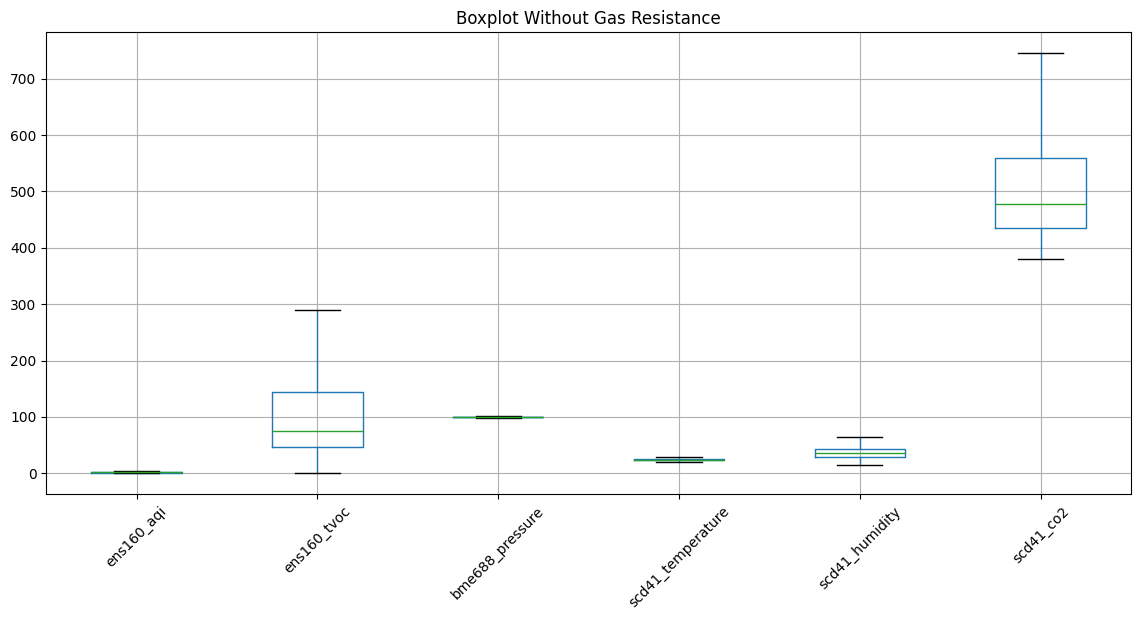

In [8]:
plot_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

feature_df[plot_cols].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot Without Gas Resistance")
plt.show()

In [9]:
# ==========================================
# Step 8 - Time-Based Split
# ==========================================

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

def split_station_data(station_data):
    station_data = station_data.sort_values("timestamp")
    n_rows = len(station_data)
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )

train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_data(station_data)
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

train_df = pd.concat(train_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)

total_rows = len(feature_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train percentage:", len(train_df) / total_rows * 100)
print("Val percentage:", len(val_df) / total_rows * 100)
print("Test percentage:", len(test_df) / total_rows * 100)

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("val"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nRows per station:")
print(split_counts)

Train shape: (130816, 14)
Val shape: (28031, 14)
Test shape: (28037, 14)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381


In [10]:
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col not in ["timestamp"]
]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
val_df_scaled[feature_cols] = x_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])
val_df_scaled[[target_col]] = y_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df[[target_col]])

print("Input features:", feature_cols)
print("Past CO2 included:", target_col in feature_cols)
print("Scaled X train min/max:", train_df_scaled[feature_cols].min().min(), train_df_scaled[feature_cols].max().max())
print("Scaled y train min/max:", train_df_scaled[target_col].min(), train_df_scaled[target_col].max())

Input features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
Past CO2 included: True
Scaled X train min/max: 0.0 1.0000000000000002
Scaled y train min/max: 0.0 1.0000000000000002


In [11]:
input_size = 60   # 60 rows * 15 min = past 15 hours
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col != "timestamp"
]

def create_windows(data, feature_cols, target_col):
    X_windows = []
    y_windows = []

    data = data.sort_values(["station_id", "timestamp"])

    for station_id, station_data in data.groupby("station_id"):
        X = station_data[feature_cols].values.astype("float32")
        y = station_data[target_col].values.astype("float32")

        # X uses previous 60 timestamps, y uses next timestamp
        # Since data is 15-min sampled, y[i] = CO2 15 min ahead
        for i in range(input_size, len(station_data)):
            X_windows.append(X[i - input_size:i])
            y_windows.append(y[i])

    return np.array(X_windows, dtype="float32"), np.array(y_windows, dtype="float32")


X_train, y_train = create_windows(train_df_scaled, feature_cols, target_col)
X_val, y_val = create_windows(val_df_scaled, feature_cols, target_col)
X_test, y_test = create_windows(test_df_scaled, feature_cols, target_col)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (130516, 60, 13) y_train: (130516,)
X_val: (27731, 60, 13) y_val: (27731,)
X_test: (27737, 60, 13) y_test: (27737,)


In [12]:
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2040
Val batches: 434
Test batches: 434


In [13]:
class TransformerRegressor(nn.Module):
    def __init__(
        self,
        num_features,
        d_model=32,
        nhead=4,
        num_layers=1,
        dim_feedforward=64,
        dropout=0.2,
        max_len=input_size
    ):
        super().__init__()

        self.input_projection = nn.Linear(num_features, d_model)

        self.positional_embedding = nn.Parameter(
            torch.zeros(1, max_len, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        seq_len = x.size(1)

        x = self.input_projection(x)
        x = x + self.positional_embedding[:, :seq_len, :]

        x = self.transformer_encoder(x)

        # Use last time step representation
        x = x[:, -1, :]

        output = self.regressor(x)
        return output

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_features = X_train.shape[2]

model = TransformerRegressor(
    num_features=num_features,
    d_model=32,
    nhead=4,
    num_layers=1,
    dim_feedforward=64,
    dropout=0.2,
    max_len=input_size
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

Device: cpu


In [15]:
num_epochs = 15
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_transformer_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/15] Train Loss: 0.008374 Val Loss: 0.001563
Epoch [2/15] Train Loss: 0.002700 Val Loss: 0.001363
Epoch [3/15] Train Loss: 0.002144 Val Loss: 0.001268
Epoch [4/15] Train Loss: 0.001911 Val Loss: 0.001520
Epoch [5/15] Train Loss: 0.001834 Val Loss: 0.001161
Epoch [6/15] Train Loss: 0.001802 Val Loss: 0.001528
Epoch [7/15] Train Loss: 0.001780 Val Loss: 0.001277
Epoch [8/15] Train Loss: 0.001773 Val Loss: 0.001196
Epoch [9/15] Train Loss: 0.001733 Val Loss: 0.001116
Epoch [10/15] Train Loss: 0.001732 Val Loss: 0.001290
Epoch [11/15] Train Loss: 0.001713 Val Loss: 0.001135
Epoch [12/15] Train Loss: 0.001712 Val Loss: 0.001197
Epoch [13/15] Train Loss: 0.001703 Val Loss: 0.001236
Epoch [14/15] Train Loss: 0.001697 Val Loss: 0.001095
Epoch [15/15] Train Loss: 0.001684 Val Loss: 0.001107


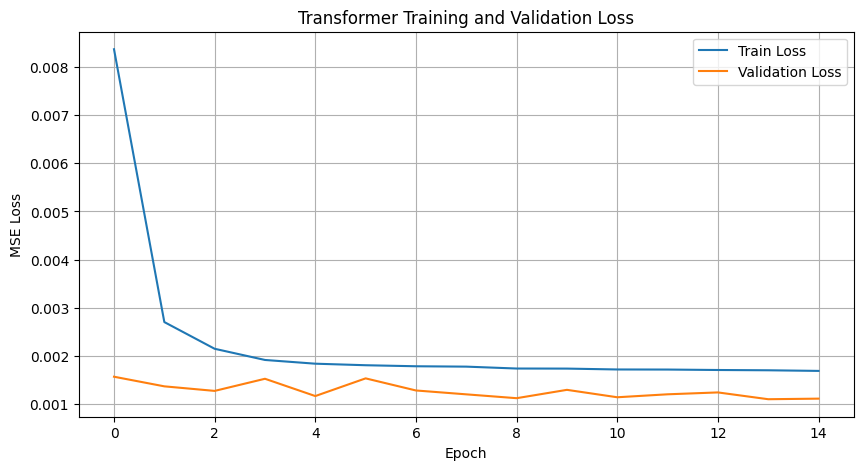

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
model.load_state_dict(torch.load("best_transformer_model.pth", map_location=device))
model.eval()

y_true_scaled = []
y_pred_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        preds = model(X_batch).cpu().numpy()

        y_pred_scaled.extend(preds)
        y_true_scaled.extend(y_batch.numpy())

y_true_scaled = np.array(y_true_scaled)
y_pred_scaled = np.array(y_pred_scaled)

y_true = y_scaler.inverse_transform(y_true_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test MSE: 72.6884994506836
Test RMSE: 8.525755066308415
Test MAE: 4.017335414886475
Test R2: 0.9939458966255188


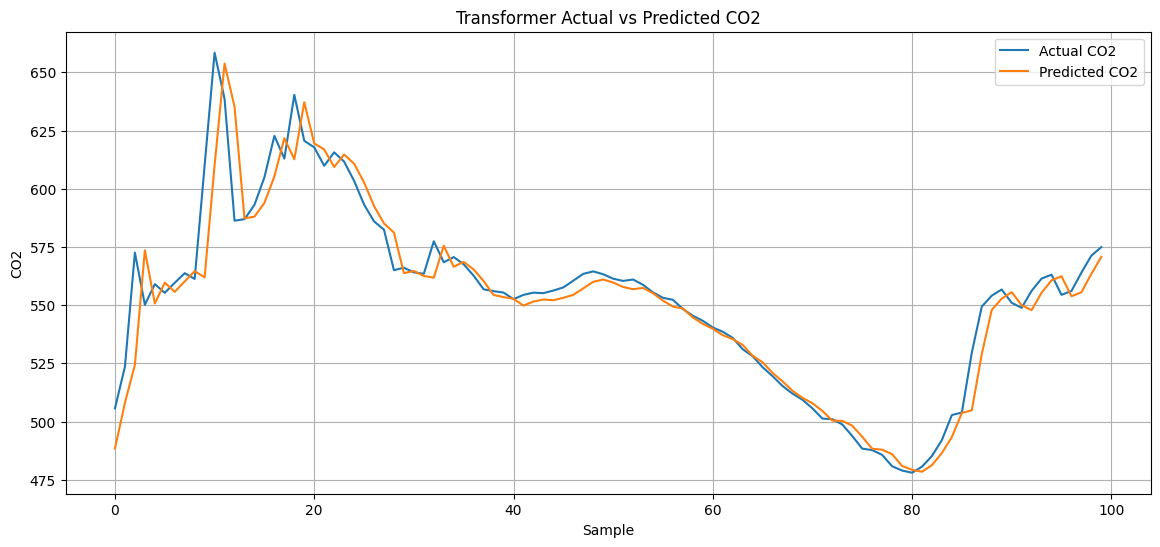

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="Actual CO2")
plt.plot(y_pred[:100], label="Predicted CO2")
plt.xlabel("Sample")
plt.ylabel("CO2")
plt.title("Transformer Actual vs Predicted CO2")
plt.legend()
plt.grid(True)
plt.show()